In [1]:
import pickle
import os
import urllib

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
from torch import nn
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from sklearn.decomposition import PCA
from scipy import signal

from dinov3.train.ssl_meta_arch import SSLMetaArch
from dinov3.models import build_model_from_cfg
from dinov3.layers.dino_head import DINOHead
from dinov3.loss.dino_clstoken_loss import DINOLoss

import yaml
from pathlib import Path

from omegaconf import DictConfig, OmegaConf
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from tqdm import tqdm

import umap
from collections import defaultdict

torch.backends.cuda.preferred_linalg_library()

<_LinalgBackend.Default: 0>

In [2]:
torch.cuda.is_available()

True

In [3]:
# ARCH = "vitb"

MODEL_ROOT = Path(f"/home/przewiez/shared_results/uj/dinov3/vitb_im1k_lin834_g8_b256_e2048/")
MODEL_ROOT = Path(f"/home/przewiez/shared_results/uj/dinov3/vitl_im1k_lin834_g16_b128_e2048/")


cfg = OmegaConf.load(MODEL_ROOT / "config.yaml")
cfg.student

{'arch': 'vit_large', 'patch_size': 16, 'drop_path_rate': 0.3, 'layerscale': 1e-05, 'pretrained_weights': '', 'ffn_layer': 'mlp', 'ffn_ratio': 4.0, 'resume_from_teacher_chkpt': '', 'qkv_bias': True, 'proj_bias': True, 'ffn_bias': True, 'norm_layer': 'layernorm', 'n_storage_tokens': 0, 'mask_k_bias': False, 'untie_cls_and_patch_norms': False, 'untie_global_and_local_cls_norm': False, 'in_chans': 3, 'pos_embed_type': 'rope', 'pos_embed_rope_base': 100.0, 'pos_embed_rope_min_period': None, 'pos_embed_rope_max_period': None, 'pos_embed_rope_normalize_coords': 'separate', 'pos_embed_rope_shift_coords': None, 'pos_embed_rope_jitter_coords': None, 'pos_embed_rope_rescale_coords': None, 'pos_embed_rope_dtype': 'bf16', 'fp8_enabled': False, 'fp8_filter': 'blocks', 'patch_drop': 0.0}

In [4]:
# dino_head

In [5]:
backbone, embed_dim = build_model_from_cfg(cfg, only_teacher=True)
dino_head = DINOHead(
                in_dim=embed_dim,
                out_dim=cfg.dino.head_n_prototypes,
                hidden_dim=cfg.dino.head_hidden_dim,
                bottleneck_dim=cfg.dino.head_bottleneck_dim,
                nlayers=cfg.dino.head_nlayers,
            )

ibot_head = DINOHead(
                in_dim=embed_dim,
                out_dim=cfg.ibot.head_n_prototypes,
                hidden_dim=cfg.ibot.head_hidden_dim,
                bottleneck_dim=cfg.ibot.head_bottleneck_dim,
                nlayers=cfg.ibot.head_nlayers,
            )

dino_loss = DINOLoss(embed_dim)

In [6]:
dino_head

DINOHead(
  (mlp): Sequential(
    (0): Linear(in_features=1024, out_features=2048, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=2048, out_features=2048, bias=True)
    (3): GELU(approximate='none')
    (4): Linear(in_features=2048, out_features=256, bias=True)
  )
  (last_layer): Linear(in_features=256, out_features=65536, bias=False)
)

In [7]:
model = nn.ModuleDict(
    dict(
        backbone=backbone,
        dino_head=dino_head,
        ibot_head=ibot_head,
    )
)

In [8]:
ckpt = torch.load(MODEL_ROOT / "eval/training_62499/teacher_checkpoint.pth")

In [9]:
ckpt["teacher"].keys();

In [10]:
model.load_state_dict(ckpt["teacher"], assign=True)

<All keys matched successfully>

In [11]:
imagenet_mean = np.array([0.485, 0.456, 0.406])
imagenet_std = np.array([0.229, 0.224, 0.225])

ds = ImageFolder(
    # "/shared/sets/datasets/vision/ImageNet/val",
    # "/shared/sets/datasets/vision/IN-100/val/",
    "/shared/sets/datasets/vision/ImageNette/val/",
    # "/home/marcin.przewiezlikowki/datasets/CUB_200_2011/images_train_test/val/",
    transform=T.Compose([
        T.Resize((224, 224)),
        T.ToTensor(),
        T.Normalize(imagenet_mean, imagenet_std)
    ])
)
dl = torch.utils.data.DataLoader(ds, batch_size=32, num_workers=4, shuffle=False, )

In [12]:
def effrank(X):
    with torch.no_grad():
        # Xs = np.concatenate(Xs, axis=0)
        U, D, V = np.linalg.svd(X)
        D_l1 = np.abs(D).sum()
        P = D / D_l1
        H = P * np.log(P)
        effr = np.exp(-H.sum())
        
        return effr
    
def effrank_gpu(X):
    with torch.no_grad():
        D = torch.linalg.svdvals(X)

        D_l1 = torch.abs(D).sum()
        P = D / D_l1
        H = P * torch.log(P)
        effr = torch.exp(-H.sum())
        
        return effr.item()

    
import torch



def activation_stats(model_outputs):
    result = dict()
    
    outputs = model_outputs
    for k, v in outputs.items():
        
        if v.shape[1] < 2000 or True:
            from time import time
            
            # s = time()
            # effr_np = effrank(v)
            # t0 = time()
            print(k, v.shape, torch.any(torch.isnan(v)))
            effr = effrank_gpu(v.cuda())
            result[(k, "effective rank")] = np.array([effr])
            result[(k, ("effective rank", "upper bound"))] = np.array([v.shape[1]])

        v_sum = v.sum(dim=1)
        if not torch.allclose(v_sum, torch.ones_like(v_sum)):
            print("applying softmax on", k)
            v = torch.softmax(v, dim=1)
            v_sum = v.sum(dim=1)

        assert torch.allclose(v_sum, torch.ones_like(v_sum)), k

        ent = -(v * (v + 1e-6).log()).sum(dim=1)
        
        o_shape = v.shape[1]
        # ent_upper_bound = -(1/o_shape) * (np.log(1/o_shape)) * o_shape

        
        ent_scaled = torch.exp(ent) / o_shape

        result[(k, "entropy")] = ent.detach().cpu().numpy()
        result[(k, ("entropy", f"upper bound for shape {o_shape}"))] = np.array([-np.log(1/o_shape)])
        
        result[(k, f"exp(entropy)_div_N")] = ent_scaled.detach().cpu().numpy()
        result[(k, ("exp(entropy)_div_N", f"upper bound"))] = np.array([1])
        
    
    return result
    

In [13]:
ckpt_dirs = sorted(
    [d for d in (MODEL_ROOT / "eval").iterdir() if d.is_dir()],
    key=lambda d: int(d.name.split("_")[1])
)


iter_to_stats = dict()

iter_to_dump_dict = dict()

for d in ckpt_dirs:
    if not d.is_dir():
        continue
    
    _, model_iter = d.name.split("_")
    model_iter = int(model_iter)
    
    # if model_iter > 15000:
    #     break
        
    ckpt = torch.load(d / "teacher_checkpoint.pth")
    model.load_state_dict(ckpt["teacher"], assign=True)

    
    stats = defaultdict(list)
    
    model_outputs = defaultdict(list)
    
    for x, y in tqdm(dl, desc=f"{model_iter=}"):
        z = model["backbone"].forward(x.cuda()) #.detach().cpu()
        
        preproto = model["dino_head"](z, no_last_layer=True)
        
        h = model["dino_head"](z)
        h_sk = dino_loss.sinkhorn_knopp_teacher(h, teacher_temp=cfg.teacher.teacher_temp)
        
        outputs = dict(
            z=z, 
            preproto=preproto,
            h=h,
            hs_sk=h_sk
        )
        
        for (k,v) in outputs.items():
            model_outputs[k].append(v.detach().cpu())
        

    model_outputs = {
        k: torch.cat(v)
        for (k,v) 
        in model_outputs.items()
    }
    
    
    stats = activation_stats(model_outputs)
    
    # assert False, {k: v.shape for (k,v) in model_outputs.items()}
    
    
    stats = {
        k: v.mean()
        for (k,v)
        in stats.items()
    }

    iter_to_stats[model_iter] = stats
    
    dump_dict = {
        "model_outputs": {
            "backbone": model_outputs["z"].detach().cpu(),
            "dino_head_before_prototypes": model_outputs["preproto"].detach().cpu(),
            # "prototypes": model_outputs["h"].detach().cpu(),
            # "prototypes_sinkhorn_knopp": model_outputs["hs_sk"].detach().cpu(),
        },
        "model": {
            "dino_head":  model["dino_head"].state_dict(),
            "dino_head_last_layer": model["dino_head"].last_layer.state_dict(),
            "sinkorn_knopp_temperature": cfg.teacher.teacher_temp
        }
    }
    
    iter_to_dump_dict[model_iter] = dump_dict

torch.save(iter_to_dump_dict, MODEL_ROOT / "prototypes_activations.pth")    
    

model_iter=6249: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 123/123 [00:12<00:00,  9.53it/s]


z torch.Size([3925, 1024]) tensor(False)
applying softmax on z
preproto torch.Size([3925, 256]) tensor(False)
applying softmax on preproto
h torch.Size([3925, 65536]) tensor(False)
applying softmax on h
hs_sk torch.Size([3925, 65536]) tensor(False)


model_iter=12499: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 123/123 [00:13<00:00,  9.29it/s]


z torch.Size([3925, 1024]) tensor(False)
applying softmax on z
preproto torch.Size([3925, 256]) tensor(False)
applying softmax on preproto
h torch.Size([3925, 65536]) tensor(False)
applying softmax on h
hs_sk torch.Size([3925, 65536]) tensor(False)


model_iter=18749: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 123/123 [00:13<00:00,  9.36it/s]


...

z torch.Size([3925, 1024]) tensor(False)
applying softmax on z
preproto torch.Size([3925, 256]) tensor(False)
applying softmax on preproto
h torch.Size([3925, 65536]) tensor(False)
applying softmax on h
hs_sk torch.Size([3925, 65536]) tensor(False)


model_iter=56249: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 123/123 [00:13<00:00,  9.43it/s]


z torch.Size([3925, 1024]) tensor(False)
applying softmax on z
preproto torch.Size([3925, 256]) tensor(False)
applying softmax on preproto
h torch.Size([3925, 65536]) tensor(False)
applying softmax on h
hs_sk torch.Size([3925, 65536]) tensor(False)


model_iter=62499: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 123/123 [00:13<00:00,  9.34it/s]


z torch.Size([3925, 1024]) tensor(False)
applying softmax on z
preproto torch.Size([3925, 256]) tensor(False)
applying softmax on preproto
h torch.Size([3925, 65536]) tensor(False)
applying softmax on h
hs_sk torch.Size([3925, 65536]) tensor(False)


In [24]:
{k: v.shape for (k,v) in dump_dict["model_outputs"].items()}

{'backbone': torch.Size([3925, 1024]),
 'dino_head_before_prototypes': torch.Size([3925, 256])}

In [39]:
torch.linalg.norm( 
dump_dict["model_outputs"]["dino_head_before_prototypes"][0], dim=-1)

tensor(1.)

In [34]:
{k: v.shape for (k,v) in dump_dict["model"]["dino_head"].items()}

{'mlp.0.weight': torch.Size([2048, 1024]),
 'mlp.0.bias': torch.Size([2048]),
 'mlp.2.weight': torch.Size([2048, 2048]),
 'mlp.2.bias': torch.Size([2048]),
 'mlp.4.weight': torch.Size([256, 2048]),
 'mlp.4.bias': torch.Size([256]),
 'last_layer.weight': torch.Size([65536, 256])}

In [31]:
k: {
        k_: v_.shape 
        if isinstance(v_, torch.Tensor) 
        else v_ for (k_,v_) in v.items() 
        if isinstance(v, dict)
    } 
    for (k,v) in dump_dict["model"].items()
}

AttributeError: 'float' object has no attribute 'items'

In [14]:
torch.backends.cuda.preferred_linalg_library()

<_LinalgBackend.Default: 0>

In [15]:
o_to_name = dict(
    z="Backbone output (softmaxed)",
    h="DINO head output (softmaxed)",
    hs_sk="DINO head (sinkhorn)",
    preproto="DINO head (pre-prototype layer)"
)

In [16]:
{k: v.shape for (k,v) in outputs.items()}

{'z': torch.Size([21, 1024]),
 'preproto': torch.Size([21, 256]),
 'h': torch.Size([21, 65536]),
 'hs_sk': torch.Size([21, 65536])}

In [17]:
# siters



In [18]:
list(iter_to_stats.values())[0].keys()

dict_keys([('z', 'effective rank'), ('z', ('effective rank', 'upper bound')), ('z', 'entropy'), ('z', ('entropy', 'upper bound for shape 1024')), ('z', 'exp(entropy)_div_N'), ('z', ('exp(entropy)_div_N', 'upper bound')), ('preproto', 'effective rank'), ('preproto', ('effective rank', 'upper bound')), ('preproto', 'entropy'), ('preproto', ('entropy', 'upper bound for shape 256')), ('preproto', 'exp(entropy)_div_N'), ('preproto', ('exp(entropy)_div_N', 'upper bound')), ('h', 'effective rank'), ('h', ('effective rank', 'upper bound')), ('h', 'entropy'), ('h', ('entropy', 'upper bound for shape 65536')), ('h', 'exp(entropy)_div_N'), ('h', ('exp(entropy)_div_N', 'upper bound')), ('hs_sk', 'effective rank'), ('hs_sk', ('effective rank', 'upper bound')), ('hs_sk', 'entropy'), ('hs_sk', ('entropy', 'upper bound for shape 65536')), ('hs_sk', 'exp(entropy)_div_N'), ('hs_sk', ('exp(entropy)_div_N', 'upper bound'))])

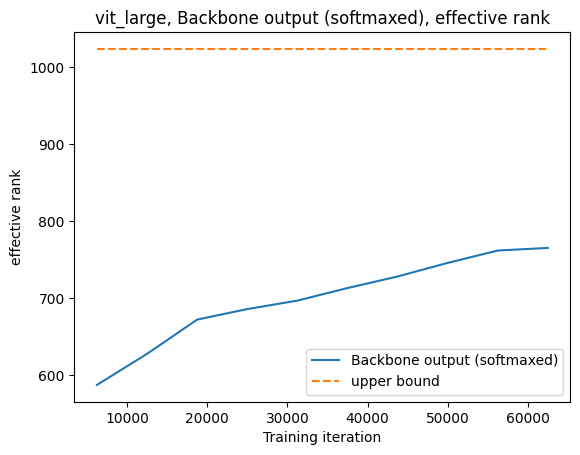

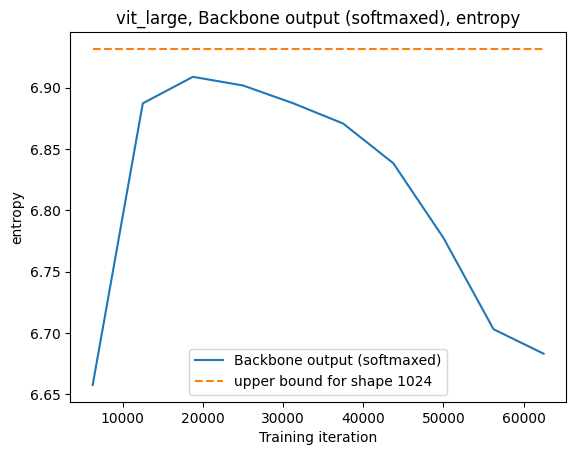

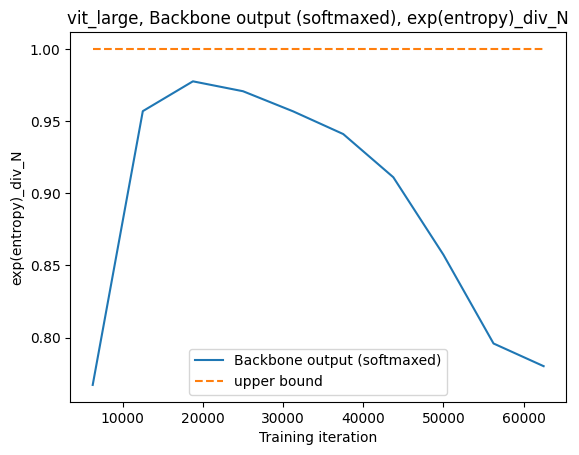

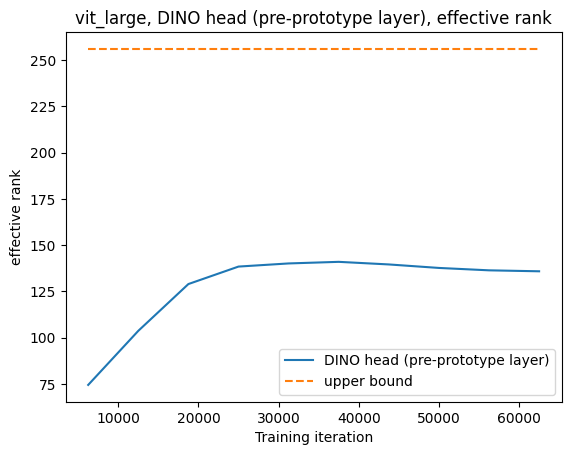

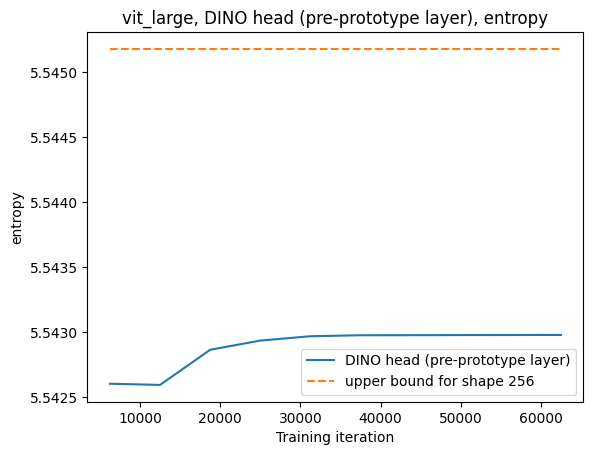

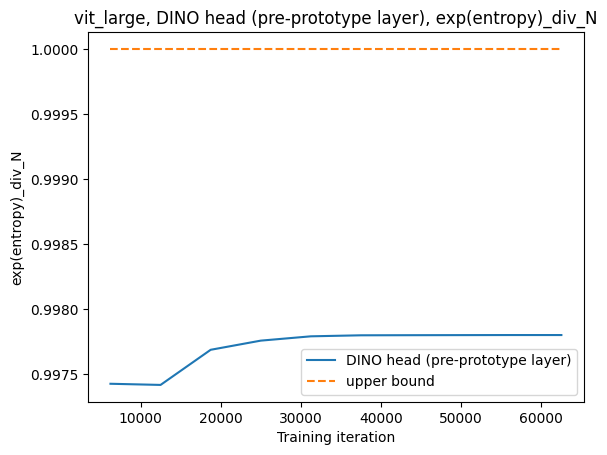

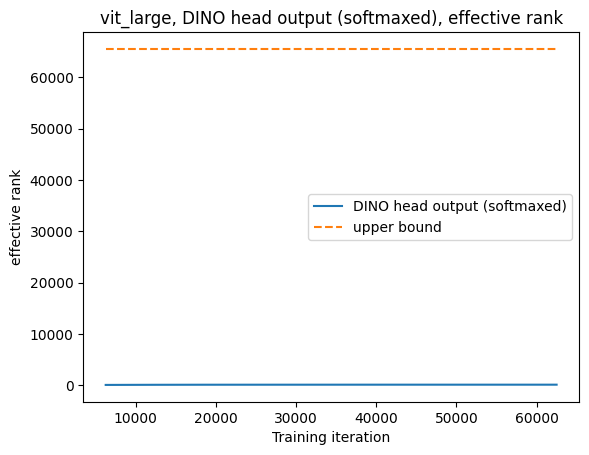

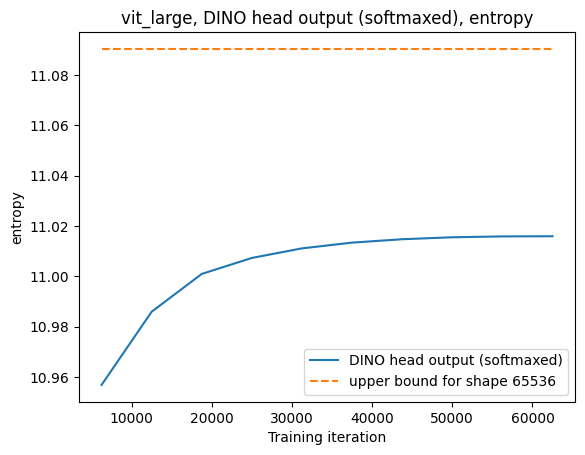

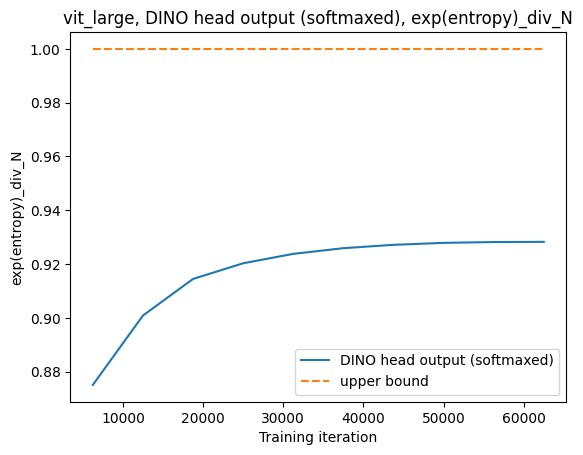

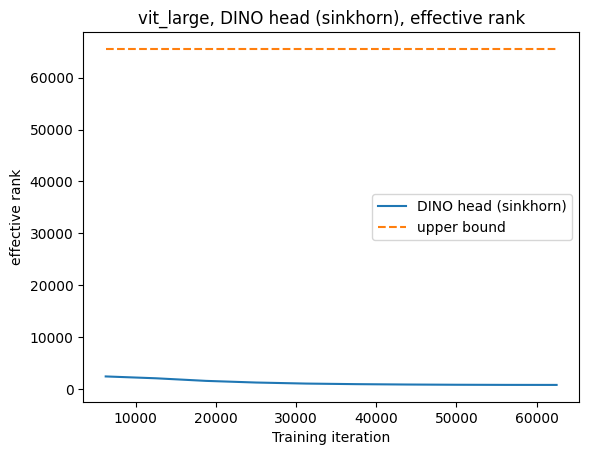

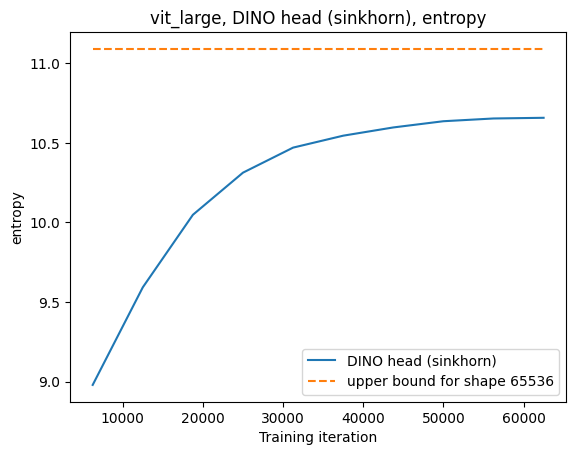

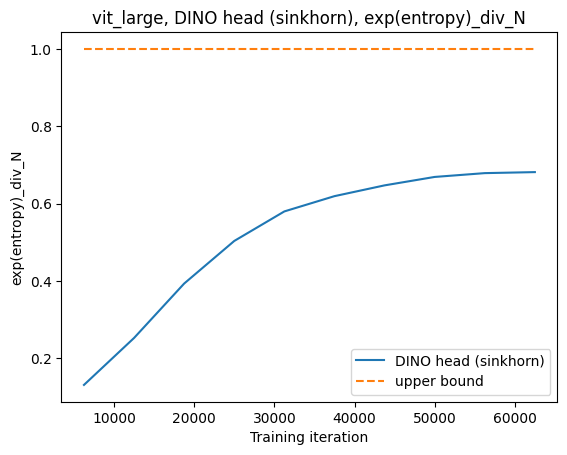

In [19]:
siters = sorted(iter_to_stats.keys())

available_metrics = list(iter_to_stats.values())[0].keys()

figs_dir = Path("entropy_plots/")


for (o_name, o_metric) in available_metrics:
    if isinstance(o_metric, tuple):
        continue
    
    plt.plot(siters, [iter_to_stats[i][(o_name, o_metric)] for i in siters], label=o_to_name[o_name])
    
    for (on, om) in available_metrics:
        if on == o_name and isinstance (om, tuple) and om[0] == o_metric:
            plt.plot(siters, [iter_to_stats[i][(on, om)] for i in siters], label=om[1], linestyle="--")
        
    plt.title(f"{cfg.student.arch}, {o_to_name[o_name]}, {o_metric}")
    plt.xlabel("Training iteration")
    plt.ylabel(o_metric)
    

    plt.legend()
    plt.savefig(figs_dir / f"{cfg.student.arch}_{o_name}_{o_metric}.png")
    plt.show()
    

# plt.legend()

In [20]:
available_metrics

dict_keys([('z', 'effective rank'), ('z', ('effective rank', 'upper bound')), ('z', 'entropy'), ('z', ('entropy', 'upper bound for shape 1024')), ('z', 'exp(entropy)_div_N'), ('z', ('exp(entropy)_div_N', 'upper bound')), ('preproto', 'effective rank'), ('preproto', ('effective rank', 'upper bound')), ('preproto', 'entropy'), ('preproto', ('entropy', 'upper bound for shape 256')), ('preproto', 'exp(entropy)_div_N'), ('preproto', ('exp(entropy)_div_N', 'upper bound')), ('h', 'effective rank'), ('h', ('effective rank', 'upper bound')), ('h', 'entropy'), ('h', ('entropy', 'upper bound for shape 65536')), ('h', 'exp(entropy)_div_N'), ('h', ('exp(entropy)_div_N', 'upper bound')), ('hs_sk', 'effective rank'), ('hs_sk', ('effective rank', 'upper bound')), ('hs_sk', 'entropy'), ('hs_sk', ('entropy', 'upper bound for shape 65536')), ('hs_sk', 'exp(entropy)_div_N'), ('hs_sk', ('exp(entropy)_div_N', 'upper bound'))])

In [21]:
iter_to_stats[62499][('hs_sk', 'effective rank')]

np.float64(806.0227661132812)